# Initial Evaluation

This notebook compares Local-Hom, Local-Het-Learned, FittedHet-LogNormMem-GammaSyn, and FittedHet-LogUniformMem-GammaSyn.

The evaluation flow is split into four stages: performance and tau comparison, zero-M z-score calibration, observed W/M sweeps, and separate null scoring of those observed sweeps.

In [24]:
from __future__ import annotations

import io
import sys
import json
import random
from contextlib import contextmanager, redirect_stdout
from copy import deepcopy
from pathlib import Path

import importlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import norm, rankdata

PROJECT_ROOT = Path('C:/Users/Priya/Desktop/research project (SNN Info Theory)')
WIMFO_ROOT = PROJECT_ROOT / 'wimfo'
PAPER_ROOT = PROJECT_ROOT / 'neural_heterogeneity' / 'SuGD_code'
for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from clipper import ZeroOneClipper
from wimfo.W_M_Info import W_M_calculator
from wimfo.utils.utils_gauss import get_cov
from data_gen import open_file, sparse_data_generator
from SuSpike import SuSpike

RSNN = importlib.import_module('model').RSNN
clipper = ZeroOneClipper()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
spike_fn = SuSpike.apply

SHD_TRAIN = PROJECT_ROOT / 'data' / 'shd' / 'shd_train.h5'
SHD_TEST = PROJECT_ROOT / 'data' / 'shd' / 'shd_test.h5'
CHECKPOINT_DIR = PROJECT_ROOT / 'Project Files' / 'Checkpoints'
OUTPUT_DIR = PROJECT_ROOT / 'Project Files'

RUN_CONFIG = {
    'm_batches': 3,
    'm_downsample_stride': 4,
    'm_ridge': 1e-2,
    'null_samples': 200,
    # Stage 3 cache controls
    'null_samples_avg': 200,
    'null_cache_namespace': 'initial_eval',
    'use_existing_null_cache_only': False,
}

print('Device:', DEVICE)
print('Train file exists:', SHD_TRAIN.exists())
print('Test file exists:', SHD_TEST.exists())
print('Checkpoint dir exists:', CHECKPOINT_DIR.exists())

Device: cuda
Train file exists: True
Test file exists: True
Checkpoint dir exists: True


In [9]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def decay_to_tau(decay, dt):
    decay = np.asarray(decay, dtype=np.float64)
    return -dt / np.log(decay)


@contextmanager
def shd_open(path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()


class SHDCache:
    def __init__(self, path):
        raw_u, raw_t, raw_l = open_file(str(path))
        self.units = list(raw_u[:])
        self.times = list(raw_t[:])
        self.labels = np.array(raw_l[:])
        raw_u._v_file.close()
        print('  SHDCache: {} samples loaded from {}'.format(len(self.labels), Path(str(path)).name))

    def __len__(self):
        return len(self.labels)


def _is_cache(obj):
    return hasattr(obj, 'units') and hasattr(obj, 'times') and hasattr(obj, 'labels')


@contextmanager
def shd_open_cached(cache):
    yield cache.units, cache.times, cache.labels


def fast_sparse_data_generator(units, times, labels, prms, shuffle=True, epoch=0, drop_last=True):
    rate = prms.get('rate', 0.0)
    p_del = prms.get('p_del', 0.0)
    if rate != 0.0 or p_del != 0.0:
        yield from sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)
        return

    seed = int(prms['seed']) + int(epoch)
    batch_size = int(prms['batch_size'])
    nb_steps = int(prms['nb_steps'])
    nb_units = int(prms['nb_inputs'])
    inv_dt = 1.0 / float(prms['time_step'])
    class_list = prms['class_list']

    label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples = len(sample_index)
    n_batches = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(sample_index)

    for counter in range(n_batches):
        batch_index = sample_index[batch_size * counter:min(num_samples, batch_size * (counter + 1))]
        actual_bs = len(batch_index)
        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths = np.array([len(arr) for arr in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            coords = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            values = torch.ones(all_ts.size, dtype=torch.float32)
            x_batch = torch.sparse_coo_tensor(coords, values, torch.Size([actual_bs, nb_steps, nb_units])).to_dense()
        else:
            x_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        x_batch.clamp_(max=1.0)
        y_batch = torch.tensor([class_list.index(int(label_arr[idx])) for idx in batch_index], dtype=torch.long)
        yield x_batch, y_batch


def shd_generator(units, times, labels, prms, shuffle, epoch, drop_last):
    yield from fast_sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)


def get_hidden_ab_tensors(model):
    hidden_layer = model.network[0]
    return hidden_layer.alpha.detach().clone(), hidden_layer.beta.detach().clone()


def summarize_hidden_taus(model, time_step: float):
    hidden_layer = model.network[0]
    alpha = hidden_layer.alpha.detach().cpu().numpy().ravel()
    beta = hidden_layer.beta.detach().cpu().numpy().ravel()
    return {
        'alpha_unique': int(np.unique(np.round(alpha, 8)).size),
        'beta_unique': int(np.unique(np.round(beta, 8)).size),
        'tau_syn_ms_min': float(decay_to_tau(alpha, time_step).min() * 1e3),
        'tau_syn_ms_max': float(decay_to_tau(alpha, time_step).max() * 1e3),
        'tau_mem_ms_min': float(decay_to_tau(beta, time_step).min() * 1e3),
        'tau_mem_ms_max': float(decay_to_tau(beta, time_step).max() * 1e3),
    }


def count_epoch_samples(sample_count, batch_size, drop_last, batch_limit=None):
    if drop_last:
        available = sample_count // batch_size
    else:
        available = -(-sample_count // batch_size)
    used = available if batch_limit is None else min(available, int(batch_limit))
    if drop_last:
        return used * batch_size
    remaining = sample_count
    total = 0
    for _ in range(used):
        take = min(batch_size, remaining)
        total += take
        remaining -= take
    return total


def select_hidden_subset(nb_hidden: int, subset_size: int = 8) -> np.ndarray:
    return np.linspace(0, nb_hidden - 1, min(subset_size, nb_hidden), dtype=int)


def gaussian_copula_normalize(data: np.ndarray) -> np.ndarray:
    transformed = np.zeros_like(data, dtype=np.float64)
    for index, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks = rankdata(row, method='average')
        uniform = np.clip((ranks - 0.5) / len(row), 1e-6, 1.0 - 1e-6)
        transformed[index] = norm.ppf(uniform)
    return transformed


def regularize_covariance(cov: np.ndarray, ridge: float = 1e-2) -> np.ndarray:
    cov = np.asarray(cov, dtype=np.float64)
    cov = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if not np.isfinite(scale) or scale <= 0.0:
        scale = 1.0
    return cov + ridge * scale * np.eye(cov.shape[0], dtype=np.float64)


@torch.no_grad()
def collect_hidden_state_matrix(model, prms, data_source, max_batches=2, subset_size=6, downsample_stride=4, subset_indices=None):
    ctx = shd_open_cached if _is_cache(data_source) else shd_open
    with ctx(data_source) as (units, times, labels):
        hidden_size = int(model.network[0].output_size)
        if subset_indices is None:
            chosen = select_hidden_subset(hidden_size, subset_size=subset_size)
        else:
            chosen = np.asarray(subset_indices, dtype=int)
        stride = max(int(downsample_stride), 1)
        chunks = []
        for batch_index, (x, _) in enumerate(shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)):
            if batch_index >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            hidden_mem = layer_recs[0][1][:, ::stride, :][:, :, chosen].detach().cpu().numpy()
            hidden_mem = np.transpose(hidden_mem, (2, 0, 1)).reshape(len(chosen), -1)
            chunks.append(hidden_mem)
    if not chunks:
        raise RuntimeError('No SHD batches were collected for M-information estimation.')
    return np.concatenate(chunks, axis=1)


def compute_w_m_from_hidden_matrix(hidden_data, lag=1, ridge=1e-2, optimiser_order=(('Adam', {'atol': 1e-3, 'rtol': 1e-3, 'max_iter': 30000}), ('Newton', None))):
    gaussian_data = gaussian_copula_normalize(hidden_data)
    last_error = None
    # Primary path: pass gaussian_data directly so wimfo handles covariance internally.
    # Avoids the sqrt(1-d) NaN that occurs in option='distr' when Adam steps d>1
    # for high-autocorrelation SNN membrane potentials at larger subset sizes.
    for optimiser, options in optimiser_order:
        try:
            with io.StringIO() as buffer, redirect_stdout(buffer):
                w_bits, m_bits = W_M_calculator(
                    gaussian_data,
                    t=lag,
                    option='data',
                    type='gaussian',
                    unit='bits',
                    verbose=False,
                    optimiser=optimiser,
                    options=options,
                )
        except Exception as exc:
            last_error = exc
            continue
        if np.isfinite(w_bits) and np.isfinite(m_bits):
            return {
                'W_bits': float(w_bits),
                'M_bits': float(m_bits),
                'samples': int(gaussian_data.shape[1]),
                'optimiser': optimiser,
            }
    # Fallback: explicit ridge-regularized covariance (original approach)
    lagged_cov = regularize_covariance(get_cov(gaussian_data, t=lag), ridge=ridge)
    for optimiser, options in optimiser_order:
        try:
            with io.StringIO() as buffer, redirect_stdout(buffer):
                w_bits, m_bits = W_M_calculator(
                    lagged_cov,
                    option='distr',
                    type='gaussian',
                    unit='bits',
                    verbose=False,
                    optimiser=optimiser,
                    options=options,
                )
        except Exception as exc:
            last_error = exc
            continue
        if np.isfinite(w_bits) and np.isfinite(m_bits):
            return {
                'W_bits': float(w_bits),
                'M_bits': float(m_bits),
                'samples': int(gaussian_data.shape[1]),
                'optimiser': optimiser,
                'lagged_cov': lagged_cov,
            }
    if last_error is not None:
        raise RuntimeError('W/M calculation failed.') from last_error
    raise RuntimeError('W/M calculation returned NaN for all tested configurations.')


def simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode='iid'):
    if mode == 'iid':
        return rng.standard_normal((nvar, nsamples))
    if mode == 'independent_ar1':
        coeffs = rng.uniform(-0.8, 0.8, size=nvar)
        noise = rng.standard_normal((nvar, nsamples))
        data = np.zeros((nvar, nsamples), dtype=np.float64)
        data[:, 0] = noise[:, 0]
        for index in range(1, nsamples):
            data[:, index] = coeffs * data[:, index - 1] + noise[:, index]
        return data
    raise ValueError('Unknown null mode: {}'.format(mode))


def zscore_from_null(observed, null_values):
    null_values = np.asarray(null_values, dtype=np.float64)
    valid = null_values[np.isfinite(null_values)]
    if valid.size == 0:
        return float('nan'), float('nan'), float('nan')
    mu = float(valid.mean())
    sigma = float(valid.std(ddof=1)) if valid.size > 1 else 0.0
    z = float((observed - mu) / sigma) if sigma > 0.0 and np.isfinite(sigma) else float('nan')
    p_upper = float((1.0 + np.sum(valid >= observed)) / (valid.size + 1.0))
    return z, mu, p_upper


def _sanitize_for_json(value):
    if isinstance(value, dict):
        return {str(key): _sanitize_for_json(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [_sanitize_for_json(item) for item in value]
    if isinstance(value, np.ndarray):
        return [_sanitize_for_json(item) for item in value.tolist()]
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, Path):
        return str(value)
    return value


def save_sweep_results(results, save_path, metadata=None):
    payload = {
        'metadata': _sanitize_for_json(metadata or {}),
        'results': _sanitize_for_json(results),
    }
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = save_path.with_suffix(save_path.suffix + '.tmp')
    with open(tmp_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(save_path)


def load_sweep_results(save_path):
    save_path = Path(save_path)
    if not save_path.exists():
        return []
    with open(save_path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    return payload.get('results', [])


def _resume_index(results):
    return {int(row['subset_size']): row for row in results if 'subset_size' in row}


def largest_valid_sweep_result(results, key_prefix='observed'):
    if key_prefix == 'observed':
        valid = [row for row in results if np.isfinite(row.get('observed_W_bits', np.nan)) and np.isfinite(row.get('observed_M_bits', np.nan))]
    else:
        valid = [row for row in results if np.isfinite(row.get('M_zscore', np.nan))]
    if not valid:
        raise RuntimeError('No valid M-information results were produced in the subset sweep.')
    valid.sort(key=lambda row: row['subset_size'])
    return valid[-1]


def normalize_history(history):
    history = history or {}
    return {
        'train_loss': list(history.get('train_loss', [])),
        'test_loss': list(history.get('test_loss', [])),
        'train_acc': list(history.get('train_acc', history.get('train_acc_v', []))),
        'test_acc': list(history.get('test_acc', history.get('test_acc_v', []))),
    }


def checkpoint_prms_for_runtime(saved_prms):
    prms = dict(saved_prms)
    prms.update({
        'dtype': torch.float,
        'device': DEVICE,
        'cuda': DEVICE.type == 'cuda',
    })
    return prms


def slugify_label(label: str) -> str:
    cleaned = []
    for ch in label.lower():
        cleaned.append(ch if ch.isalnum() else '_')
    slug = ''.join(cleaned)
    while '__' in slug:
        slug = slug.replace('__', '_')
    return slug.strip('_')


print('Helper functions loaded.')

Helper functions loaded.


In [10]:
NETWORK_SPECS = [
    {
        'label': 'Local-Hom',
        'checkpoint_path': CHECKPOINT_DIR / 'local_hom_checkpoint.pt',
        'color': '#4c78a8',
        'kind': 'homogeneous',
    },
    {
        'label': 'Local-Het-Learned',
        'checkpoint_path': CHECKPOINT_DIR / 'network_A_checkpoint.pt',
        'color': '#f58518',
        'kind': 'heterogeneous',
    },
    {
        'label': 'FittedHet-LogNormMem-GammaSyn',
        'checkpoint_path': CHECKPOINT_DIR / 'fittedhet_lognorm_mem_gamma_syn_checkpoint.pt',
        'color': '#54a24b',
        'kind': 'heterogeneous',
    },
    {
        'label': 'FittedHet-LogUniformMem-GammaSyn',
        'checkpoint_path': CHECKPOINT_DIR / 'fittedhet_loguniform_mem_gamma_syn_checkpoint.pt',
        'color': '#e45756',
        'kind': 'heterogeneous',
    },
]
NETWORK_ORDER = [spec['label'] for spec in NETWORK_SPECS]
HETERO_LABELS = [spec['label'] for spec in NETWORK_SPECS if spec['kind'] == 'heterogeneous']
COLORS = {spec['label']: spec['color'] for spec in NETWORK_SPECS}

for spec in NETWORK_SPECS:
    if not spec['checkpoint_path'].exists():
        raise FileNotFoundError('Missing checkpoint: {}'.format(spec['checkpoint_path']))

print('Pre-loading SHD test data into RAM...')
SHD_TEST_CACHE = SHDCache(SHD_TEST)

network_records = {}
evaluation_results = {}
for spec in NETWORK_SPECS:
    checkpoint = torch.load(spec['checkpoint_path'], map_location=DEVICE, weights_only=False)
    prms = checkpoint_prms_for_runtime(checkpoint['prms'])
    set_seed(int(prms.get('seed', 1000)))
    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    history = normalize_history(checkpoint.get('history'))
    alpha_after, beta_after = get_hidden_ab_tensors(model)
    after_summary = summarize_hidden_taus(model, prms['time_step'])
    tau_syn_ms = decay_to_tau(alpha_after.detach().cpu().numpy().ravel(), prms['time_step']) * 1e3
    tau_mem_ms = decay_to_tau(beta_after.detach().cpu().numpy().ravel(), prms['time_step']) * 1e3
    final_test_acc = float(history['test_acc'][-1]) if history['test_acc'] else float('nan')
    network_records[spec['label']] = {
        'label': spec['label'],
        'kind': spec['kind'],
        'checkpoint_path': spec['checkpoint_path'],
        'checkpoint': checkpoint,
        'model': model,
        'prms': prms,
        'history': history,
        'elapsed_s': float(checkpoint.get('elapsed_s', float('nan'))),
        'alpha_after': alpha_after,
        'beta_after': beta_after,
        'after_summary': after_summary,
        'tau_syn_ms': tau_syn_ms,
        'tau_mem_ms': tau_mem_ms,
        'distribution_family': checkpoint.get('distribution_family'),
        'color': spec['color'],
        'final_test_acc': final_test_acc,
    }
    evaluation_results[spec['label']] = {
        'test_acc': final_test_acc,
        'elapsed_s': float(checkpoint.get('elapsed_s', float('nan'))),
        'final_summary': after_summary,
        'checkpoint_path': str(spec['checkpoint_path']),
        'distribution_family': checkpoint.get('distribution_family'),
    }
    print('Loaded {} | final test acc={:.3f} | checkpoint={}'.format(spec['label'], final_test_acc, spec['checkpoint_path'].name))

Pre-loading SHD test data into RAM...
  SHDCache: 2264 samples loaded from shd_test.h5
Loaded Local-Hom | final test acc=0.652 | checkpoint=local_hom_checkpoint.pt
Loaded Local-Het-Learned | final test acc=0.649 | checkpoint=network_A_checkpoint.pt
Loaded FittedHet-LogNormMem-GammaSyn | final test acc=0.690 | checkpoint=fittedhet_lognorm_mem_gamma_syn_checkpoint.pt
Loaded FittedHet-LogUniformMem-GammaSyn | final test acc=0.601 | checkpoint=fittedhet_loguniform_mem_gamma_syn_checkpoint.pt


## Performance and Tau Comparison

Compare training histories, final SHD accuracy, and final tau distributions across the four networks.

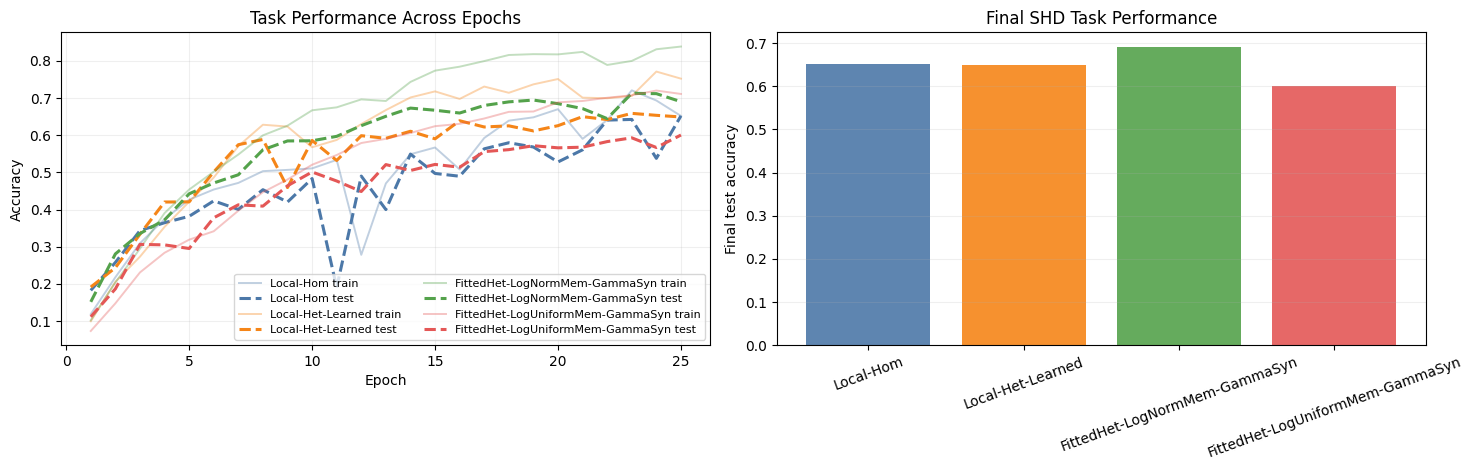

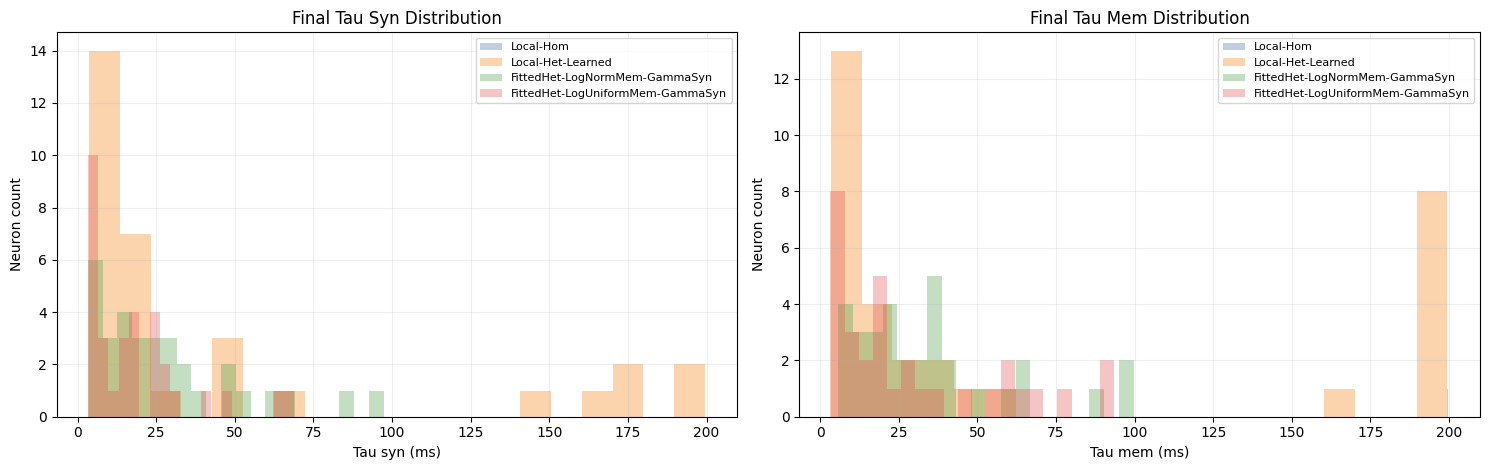

Final test accuracy ranking
------------------------------------------------------------
FittedHet-LogNormMem-GammaSyn    0.690
Local-Hom                        0.652
Local-Het-Learned                0.649
FittedHet-LogUniformMem-GammaSyn 0.601


In [5]:
required_names = ['network_records', 'evaluation_results', 'NETWORK_ORDER', 'COLORS']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError('Run the checkpoint loading cell first. Missing: {}'.format(missing))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for label in NETWORK_ORDER:
    history = network_records[label]['history']
    epochs = np.arange(1, len(history['test_acc']) + 1)
    if history['train_acc']:
        axes[0].plot(epochs, history['train_acc'], color=COLORS[label], alpha=0.35, linewidth=1.4, label='{} train'.format(label))
    if history['test_acc']:
        axes[0].plot(epochs, history['test_acc'], color=COLORS[label], linestyle='--', linewidth=2.2, label='{} test'.format(label))
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Task Performance Across Epochs')
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8, ncol=2)

final_accs = [evaluation_results[label]['test_acc'] for label in NETWORK_ORDER]
axes[1].bar(NETWORK_ORDER, final_accs, color=[COLORS[label] for label in NETWORK_ORDER], alpha=0.9)
axes[1].set_ylabel('Final test accuracy')
axes[1].set_title('Final SHD Task Performance')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for label in NETWORK_ORDER:
    axes[0].hist(network_records[label]['tau_syn_ms'], bins=20, alpha=0.35, color=COLORS[label], label=label)
    axes[1].hist(network_records[label]['tau_mem_ms'], bins=20, alpha=0.35, color=COLORS[label], label=label)
axes[0].set_xlabel('Tau syn (ms)')
axes[0].set_ylabel('Neuron count')
axes[0].set_title('Final Tau Syn Distribution')
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)
axes[1].set_xlabel('Tau mem (ms)')
axes[1].set_ylabel('Neuron count')
axes[1].set_title('Final Tau Mem Distribution')
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

ranking = sorted(((label, evaluation_results[label]['test_acc']) for label in NETWORK_ORDER), key=lambda item: item[1], reverse=True)
print('Final test accuracy ranking')
print('-' * 60)
for label, value in ranking:
    print('{:32s} {:.3f}'.format(label, value))

In [6]:
tau_distributions = {
    'run_config': RUN_CONFIG,
    'networks': {
        label: {
            'kind': network_records[label]['kind'],
            'checkpoint_path': str(network_records[label]['checkpoint_path']),
            'distribution_family': network_records[label]['distribution_family'],
            'final_test_acc': evaluation_results[label]['test_acc'],
            'final': network_records[label]['after_summary'],
            'tau_syn_ms': network_records[label]['tau_syn_ms'],
            'tau_mem_ms': network_records[label]['tau_mem_ms'],
        }
        for label in NETWORK_ORDER
    },
}

save_path = OUTPUT_DIR / 'Initial Evaluation Tau Distributions.json'
with open(save_path, 'w', encoding='utf-8') as handle:
    json.dump(_sanitize_for_json(tau_distributions), handle, indent=2)

print('Saved tau distributions to:', save_path)

Saved tau distributions to: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Initial Evaluation Tau Distributions.json


## Stage 1 — Establish Z-Scoring

Calibrate the zero-M Gaussian null z-scoring system on synthetic null-vs-null samples before running any observed W/M subset sweep.

In [4]:
required_names = ['network_records', 'RUN_CONFIG', 'SHD_TEST_CACHE']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError('Run the checkpoint loading cell first. Missing: {}'.format(missing))

reference_prms = next(iter(network_records.values()))['prms']
test_total = int(np.isin(SHD_TEST_CACHE.labels, reference_prms['class_list']).sum())
calibration_stride = RUN_CONFIG['m_downsample_stride']
calibration_timepoints = int(np.ceil(reference_prms['nb_steps'] / calibration_stride))
calibration_sample_count = count_epoch_samples(test_total, reference_prms['batch_size'], drop_last=False, batch_limit=RUN_CONFIG['m_batches']) * calibration_timepoints
CALIBRATION_CONFIG = {
    'subset_sizes': [2, 4, 6],
    'repeats': 6,
    'null_draws': min(40, RUN_CONFIG['null_samples']),
}

zscore_calibration = []
for subset_size in CALIBRATION_CONFIG['subset_sizes']:
    subset_rows = []
    for trial in range(CALIBRATION_CONFIG['repeats']):
        rng = np.random.default_rng(100000 + subset_size * 100 + trial)
        observed_hidden = simulate_zero_m_gaussian_hidden(subset_size, calibration_sample_count, rng, mode='iid')
        try:
            observed = compute_w_m_from_hidden_matrix(observed_hidden, lag=1, ridge=RUN_CONFIG['m_ridge'])
        except Exception as exc:
            row = {
                'subset_size': int(subset_size),
                'trial': int(trial),
                'status': 'error',
                'error': str(exc),
            }
            subset_rows.append(row)
            zscore_calibration.append(row)
            continue

        null_w = []
        null_m = []
        errors = 0
        for _ in range(CALIBRATION_CONFIG['null_draws']):
            null_hidden = simulate_zero_m_gaussian_hidden(subset_size, calibration_sample_count, rng, mode='iid')
            try:
                null_result = compute_w_m_from_hidden_matrix(null_hidden, lag=1, ridge=RUN_CONFIG['m_ridge'])
                null_w.append(null_result['W_bits'])
                null_m.append(null_result['M_bits'])
            except Exception:
                null_w.append(float('nan'))
                null_m.append(float('nan'))
                errors += 1

        m_z, m_mu, m_p = zscore_from_null(observed['M_bits'], null_m)
        w_z, w_mu, w_p = zscore_from_null(observed['W_bits'], null_w)
        row = {
            'subset_size': int(subset_size),
            'trial': int(trial),
            'status': 'ok',
            'samples': int(observed['samples']),
            'observed_W_bits': float(observed['W_bits']),
            'observed_M_bits': float(observed['M_bits']),
            'null_W_mean': float(w_mu),
            'null_M_mean': float(m_mu),
            'W_zscore': float(w_z),
            'M_zscore': float(m_z),
            'W_p_upper': float(w_p),
            'M_p_upper': float(m_p),
            'n_null_errors': int(errors),
            'n_null_valid_W': int(np.isfinite(np.asarray(null_w, dtype=np.float64)).sum()),
            'n_null_valid_M': int(np.isfinite(np.asarray(null_m, dtype=np.float64)).sum()),
        }
        subset_rows.append(row)
        zscore_calibration.append(row)

    valid = [row for row in subset_rows if np.isfinite(row.get('M_zscore', np.nan))]
    if valid:
        z_vals = np.array([row['M_zscore'] for row in valid], dtype=float)
        p_vals = np.array([row['M_p_upper'] for row in valid], dtype=float)
        z_std = float(np.std(z_vals, ddof=1)) if z_vals.size > 1 else 0.0
        print('subset={:02d}  mean_z={:.2f}  std_z={:.2f}  frac_p<0.05={:.2f}'.format(subset_size, np.mean(z_vals), z_std, np.mean(p_vals < 0.05)))
    else:
        print('subset={:02d}  calibration failed for all trials'.format(subset_size))

calibration_path = OUTPUT_DIR / 'Initial Evaluation Z Score Calibration.json'
with open(calibration_path, 'w', encoding='utf-8') as handle:
    json.dump(_sanitize_for_json({
        'config': CALIBRATION_CONFIG,
        'sample_count': calibration_sample_count,
        'results': zscore_calibration,
    }), handle, indent=2)

print('Saved z-score calibration to:', calibration_path)

subset=02  mean_z=-0.08  std_z=0.85  frac_p<0.05=0.00
subset=04  mean_z=0.18  std_z=0.57  frac_p<0.05=0.00
subset=06  mean_z=0.55  std_z=1.01  frac_p<0.05=0.00
Saved z-score calibration to: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Initial Evaluation Z Score Calibration.json


## Stage 2 — Observed W/M Sweeps

Run the observed subset-size W/M sweep separately from any null distribution so estimator failures show up directly in the saved results.

In [16]:
required_names = ['network_records', 'evaluation_results', 'NETWORK_ORDER', 'SHD_TEST_CACHE']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError('Run the checkpoint loading cell first. Missing: {}'.format(missing))

def hidden_matrix_diagnostics(hidden_data):
    centered = hidden_data - hidden_data.mean(axis=1, keepdims=True)
    variances = np.var(centered, axis=1)
    diagnostics = {
        'matrix_rank': int(np.linalg.matrix_rank(centered)),
        'min_variance': float(variances.min()) if variances.size else float('nan'),
        'max_variance': float(variances.max()) if variances.size else float('nan'),
        'near_constant_count': int(np.sum(variances < 1e-12)),
    }
    try:
        cov = np.cov(centered)
        if np.ndim(cov) == 0:
            diagnostics['condition_number'] = 1.0
        else:
            diagnostics['condition_number'] = float(np.linalg.cond(regularize_covariance(cov, ridge=1e-8)))
    except Exception:
        diagnostics['condition_number'] = float('nan')
    return diagnostics


def _boundary_aware_lagged_covariance(gaussian_data, lag, sequence_length, ridge):
    if sequence_length is None:
        return None, 0
    sequence_length = int(sequence_length)
    lag = int(lag)
    total = int(gaussian_data.shape[1])
    if sequence_length <= lag or total <= lag:
        return None, 0

    # Keep only lag pairs that stay inside each per-sample sequence.
    idx = np.arange(total - lag, dtype=np.int64)
    valid = ((idx % sequence_length) + lag) < sequence_length
    idx = idx[valid]
    if idx.size == 0:
        return None, 0

    past = gaussian_data[:, idx]
    future = gaussian_data[:, idx + lag]
    lagged_cov = regularize_covariance(np.cov(np.vstack([past, future])), ridge=ridge)
    return lagged_cov, int(idx.size)


def _compute_w_m_from_lagged_cov(lagged_cov, optimiser_order=(("Adam", {'atol': 1e-3, 'rtol': 1e-3, 'max_iter': 30000}), ("Newton", None))):
    last_error = None
    for optimiser, options in optimiser_order:
        try:
            with io.StringIO() as buffer, redirect_stdout(buffer):
                w_bits, m_bits = W_M_calculator(
                    lagged_cov,
                    option='distr',
                    type='gaussian',
                    unit='bits',
                    verbose=False,
                    optimiser=optimiser,
                    options=options,
                )
        except Exception as exc:
            last_error = exc
            continue
        if np.isfinite(w_bits) and np.isfinite(m_bits):
            return {
                'W_bits': float(w_bits),
                'M_bits': float(m_bits),
                'optimiser': optimiser,
            }
    if last_error is not None:
        raise RuntimeError('Boundary-aware W/M calculation failed.') from last_error
    raise RuntimeError('Boundary-aware W/M calculation returned NaN for all tested configurations.')


def observed_w_m_for_subset(model, prms, data_source, subset_size, max_batches=2, lag=1, downsample_stride=4, ridge=1e-2):
    hidden_data = collect_hidden_state_matrix(model, prms, data_source, max_batches=max_batches, subset_size=subset_size, downsample_stride=downsample_stride)
    diagnostics = hidden_matrix_diagnostics(hidden_data)
    sequence_length = int(np.ceil(int(prms['nb_steps']) / max(int(downsample_stride), 1)))
    result = {
        'subset_size': int(subset_size),
        'samples': int(hidden_data.shape[1]),
        'lag': int(lag),
        'downsample_stride': int(downsample_stride),
        'ridge': float(ridge),
        'sequence_length': int(sequence_length),
        'matrix_rank': diagnostics['matrix_rank'],
        'min_variance': diagnostics['min_variance'],
        'max_variance': diagnostics['max_variance'],
        'near_constant_count': diagnostics['near_constant_count'],
        'condition_number': diagnostics['condition_number'],
    }

    gaussian_data = gaussian_copula_normalize(hidden_data)

    # Primary: boundary-aware covariance with adaptive ridge escalation.
    ridge_multipliers = [1.0, 3.0, 10.0, 30.0, 100.0]
    boundary_errors = []
    for mult in ridge_multipliers:
        eff_ridge = float(ridge * mult)
        lagged_cov, valid_pairs = _boundary_aware_lagged_covariance(
            gaussian_data,
            lag=lag,
            sequence_length=sequence_length,
            ridge=eff_ridge,
        )
        if lagged_cov is None:
            continue
        result['valid_lag_pairs'] = int(valid_pairs)
        try:
            observed = _compute_w_m_from_lagged_cov(lagged_cov)
            result.update({
                'observed_W_bits': float(observed['W_bits']),
                'observed_M_bits': float(observed['M_bits']),
                'optimiser': observed.get('optimiser'),
                'estimator': 'boundary_aware_distr',
                'effective_ridge': eff_ridge,
                'status': 'ok',
            })
            return result
        except Exception as exc:
            boundary_errors.append('ridge={:.3g}: {}'.format(eff_ridge, exc))

    if boundary_errors:
        result['boundary_aware_error'] = ' | '.join(boundary_errors)

    # Fallback: original helper path.
    try:
        observed = compute_w_m_from_hidden_matrix(hidden_data, lag=lag, ridge=ridge)
        result.update({
            'observed_W_bits': float(observed['W_bits']),
            'observed_M_bits': float(observed['M_bits']),
            'optimiser': observed.get('optimiser'),
            'estimator': 'default_helper',
            'status': 'ok',
        })
    except Exception as exc:
        result.update({
            'observed_W_bits': float('nan'),
            'observed_M_bits': float('nan'),
            'status': 'error',
            'error': str(exc),
        })
    return result


def sweep_observed_w_m_by_subset(model, prms, data_source, subset_sizes=None, max_batches=2, lag=1, downsample_stride=4, ridge=1e-2, save_path=None, resume=True, label=None):
    hidden_size = int(model.network[0].output_size)
    if subset_sizes is None:
        subset_sizes = list(range(2, hidden_size + 1))
    existing_results = load_sweep_results(save_path) if resume and save_path is not None else []
    cached_by_subset = _resume_index(existing_results)
    results = []
    metadata = {
        'label': label,
        'hidden_size': hidden_size,
        'max_batches': max_batches,
        'lag': lag,
        'downsample_stride': downsample_stride,
        'ridge': ridge,
        'estimator': 'boundary_aware_distr_adaptive_ridge',
    }
    for subset_size in subset_sizes:
        subset_size = int(subset_size)
        if subset_size < 2 or subset_size > hidden_size:
            continue
        cached = cached_by_subset.get(subset_size)
        if cached is not None and np.isfinite(cached.get('observed_M_bits', np.nan)) and np.isfinite(cached.get('observed_W_bits', np.nan)):
            results.append(cached)
            print('subset={:02d}  resumed observed  M={:.4f}'.format(subset_size, cached.get('observed_M_bits', float('nan'))))
            continue
        if cached is not None:
            print('subset={:02d}  cached invalid -> recomputing'.format(subset_size))

        result = observed_w_m_for_subset(model, prms, data_source, subset_size=subset_size, max_batches=max_batches, lag=lag, downsample_stride=downsample_stride, ridge=ridge)
        if result['status'] == 'ok':
            print('subset={:02d}  obsM={:.4f}  obsW={:.4f}  estimator={} ridge={:.3g}'.format(subset_size, result['observed_M_bits'], result['observed_W_bits'], result.get('estimator', 'unknown'), result.get('effective_ridge', ridge)))
        else:
            print('subset={:02d}  ERROR  {} | rank={} near_constant={} min_var={:.3e}'.format(subset_size, result['error'], result['matrix_rank'], result['near_constant_count'], result['min_variance']))
        results.append(result)
        if save_path is not None:
            save_sweep_results(results, save_path, metadata=metadata)
            print('  saved -> {}'.format(Path(save_path).name))
    return results


hidden_size = int(next(iter(network_records.values()))['model'].network[0].output_size)
subset_sizes = list(range(2, hidden_size + 1))
observed_wm_sweeps = {}
comparison_results = deepcopy(evaluation_results)
for label in NETWORK_ORDER:
    record = network_records[label]
    save_path = OUTPUT_DIR / 'initial_eval_{}_observed_wm_sweep.json'.format(slugify_label(label))
    print('Running observed W/M sweep for {}...\nAutosave file: {}'.format(label, save_path.name))
    sweep = sweep_observed_w_m_by_subset(record['model'], prms=record['prms'], data_source=SHD_TEST_CACHE, subset_sizes=subset_sizes, max_batches=RUN_CONFIG['m_batches'], downsample_stride=RUN_CONFIG['m_downsample_stride'], ridge=RUN_CONFIG['m_ridge'], save_path=save_path, resume=True, label=label)
    observed_wm_sweeps[label] = sweep
    comparison_results[label]['observed_wm_sweep'] = sweep
    comparison_results[label]['observed_wm_path'] = str(save_path)
    meta = largest_valid_sweep_result(sweep, key_prefix='observed')
    comparison_results[label]['observed_meta'] = meta
    comparison_results[label]['M_bits'] = meta['observed_M_bits']
    comparison_results[label]['W_bits'] = meta['observed_W_bits']
    full_result = next((row for row in sweep if row['subset_size'] == hidden_size), None)
    print('\n{} observed sweep summary'.format(label))
    print('-' * 60)
    if full_result is not None and np.isfinite(full_result.get('observed_M_bits', np.nan)):
        print('subset=32  observed M={:.4f}  observed W={:.4f}'.format(full_result['observed_M_bits'], full_result['observed_W_bits']))
    elif full_result is not None:
        print('subset=32  failed  {}'.format(full_result.get('error', 'unknown error')))
    print('largest valid subset={:02d}  observed M={:.4f}  observed W={:.4f}'.format(meta['subset_size'], meta['observed_M_bits'], meta['observed_W_bits']))

Running observed W/M sweep for Local-Hom...
Autosave file: initial_eval_local_hom_observed_wm_sweep.json
subset=02  resumed observed  M=0.0014
subset=03  resumed observed  M=0.0296
subset=04  resumed observed  M=0.0137
subset=05  resumed observed  M=0.0720
subset=06  resumed observed  M=0.1209
subset=07  resumed observed  M=0.1776
subset=08  resumed observed  M=0.0825
subset=09  cached invalid -> recomputing
subset=09  obsM=0.1429  obsW=10.9893  estimator=boundary_aware_distr ridge=0.03
  saved -> initial_eval_local_hom_observed_wm_sweep.json
subset=10  cached invalid -> recomputing
subset=10  obsM=0.2199  obsW=11.4615  estimator=boundary_aware_distr ridge=0.03
  saved -> initial_eval_local_hom_observed_wm_sweep.json
subset=11  cached invalid -> recomputing
subset=11  obsM=0.1539  obsW=13.6980  estimator=boundary_aware_distr ridge=0.03
  saved -> initial_eval_local_hom_observed_wm_sweep.json
subset=12  cached invalid -> recomputing
subset=12  obsM=0.1708  obsW=14.7610  estimator=bounda

## Stage 3 — Apply Zero-M Null Scoring to Observed Sweeps

Generate the Gaussian zero-M null distribution separately for each observed subset result and score observed W/M against that subset-matched null.

In [ ]:
required_names = ['observed_wm_sweeps', 'comparison_results', 'NETWORK_ORDER']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError('Run Stage 2 first. Missing: {}'.format(missing))


def _null_cache_key(nvar, nsamples, lag, ridge, n_null, null_mode):
    # Use a stable string key so cache can be persisted to JSON.
    key_parts = [int(nvar), int(nsamples), int(lag), float(ridge), int(n_null), str(null_mode)]
    return json.dumps(key_parts, separators=(',', ':'))


def _cache_file_name(cache_namespace, null_mode, lag, ridge, n_null, solver_tag):
    namespace = slugify_label(str(cache_namespace)) or 'cache'
    ridge_tag = '{:.0e}'.format(float(ridge)).replace('+', '')
    return '{}_zero_m_subset_null_cache_{}_lag{}_ridge{}_n{}_{}.json'.format(
        namespace,
        str(null_mode),
        int(lag),
        ridge_tag,
        int(n_null),
        str(solver_tag),
    )


def _compute_w_m_from_null_hidden_fast(null_hidden, lag=1, ridge=1e-2):
    # Null draws are already Gaussian; covariance + Newton is the fastest stable path.
    lagged_cov = regularize_covariance(get_cov(null_hidden, t=lag), ridge=ridge)
    with io.StringIO() as buffer, redirect_stdout(buffer):
        w_bits, m_bits = W_M_calculator(
            lagged_cov,
            option='distr',
            type='gaussian',
            unit='bits',
            verbose=False,
            optimiser='Newton',
            options=None,
        )
    if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
        raise RuntimeError('Fast null W/M calculation returned non-finite values.')
    return {
        'W_bits': float(w_bits),
        'M_bits': float(m_bits),
        'optimiser': 'Newton',
    }


def _coerce_float_list(values):
    out = []
    for value in values:
        try:
            out.append(float(value))
        except Exception:
            out.append(float('nan'))
    return out


def _make_null_distribution(null_w, null_m, n_null_target, null_mode, fast_null_solver):
    null_w_arr = np.asarray(null_w, dtype=np.float64)
    null_m_arr = np.asarray(null_m, dtype=np.float64)
    valid_pair = np.isfinite(null_w_arr) & np.isfinite(null_m_arr)
    errors = int(valid_pair.size - int(valid_pair.sum()))
    return {
        'null_W_values': [float(v) if np.isfinite(v) else float('nan') for v in null_w_arr],
        'null_M_values': [float(v) if np.isfinite(v) else float('nan') for v in null_m_arr],
        'n_null': int(n_null_target),
        'n_null_generated': int(null_w_arr.size),
        'n_null_errors': int(errors),
        'n_null_valid_W': int(np.isfinite(null_w_arr).sum()),
        'n_null_valid_M': int(np.isfinite(null_m_arr).sum()),
        'null_mode': str(null_mode),
        'null_solver': 'fast_distr_newton' if fast_null_solver else 'full_data_path',
    }


def build_zero_m_null_distribution(nvar, nsamples, lag=1, ridge=1e-2, n_null=200, null_mode='iid', seed=12345, cache=None, cache_key=None, fast_null_solver=True, cache_save_callback=None, save_every=20, progress_label=None):
    target_n = int(n_null)

    null_w = []
    null_m = []
    if cache is not None and cache_key is not None and cache_key in cache:
        existing = cache[cache_key]
        null_w = _coerce_float_list(existing.get('null_W_values', []))
        null_m = _coerce_float_list(existing.get('null_M_values', []))
        paired_len = min(len(null_w), len(null_m))
        null_w = null_w[:paired_len]
        null_m = null_m[:paired_len]
        if paired_len >= target_n:
            return _make_null_distribution(null_w[:target_n], null_m[:target_n], target_n, null_mode, fast_null_solver)

    start_idx = len(null_w)

    # Recreate RNG state up to start_idx so resumed runs remain deterministic.
    rng = np.random.default_rng(seed)
    for _ in range(start_idx):
        _ = simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode=null_mode)

    for draw_index in range(start_idx, target_n):
        null_hidden = simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode=null_mode)
        try:
            if fast_null_solver:
                null_result = _compute_w_m_from_null_hidden_fast(null_hidden, lag=lag, ridge=ridge)
            else:
                null_result = compute_w_m_from_hidden_matrix(null_hidden, lag=lag, ridge=ridge)
            null_w.append(float(null_result['W_bits']))
            null_m.append(float(null_result['M_bits']))
        except Exception:
            null_w.append(float('nan'))
            null_m.append(float('nan'))

        if cache is not None and cache_key is not None:
            cache[cache_key] = _make_null_distribution(null_w, null_m, target_n, null_mode, fast_null_solver)
            if cache_save_callback is not None and (((draw_index + 1) % max(1, int(save_every)) == 0) or (draw_index + 1 == target_n)):
                cache_save_callback(cache)

        if progress_label is not None and (((draw_index + 1) % 50 == 0) or (draw_index + 1 == target_n)):
            print('{} draws {}/{}'.format(progress_label, draw_index + 1, target_n))

    distribution = _make_null_distribution(null_w, null_m, target_n, null_mode, fast_null_solver)
    if cache is not None and cache_key is not None:
        cache[cache_key] = distribution
    return distribution


def load_null_cache(cache_path):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return {}, {}
    with open(cache_path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        return {}, {}
    metadata = payload.get('metadata', {})
    cache = payload.get('cache', {})
    if not isinstance(metadata, dict):
        metadata = {}
    if not isinstance(cache, dict):
        cache = {}
    return metadata, cache


def save_null_cache(cache, cache_path, metadata=None):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = cache_path.with_suffix(cache_path.suffix + '.tmp')
    payload = {
        'metadata': _sanitize_for_json(metadata or {}),
        'cache': _sanitize_for_json(cache),
    }
    with open(tmp_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(cache_path)


def prepare_shared_null_cache(observed_sweeps_by_network, lag=1, ridge=1e-2, n_null=200, null_mode='iid', cache=None, cache_path=None, cache_metadata=None, fast_null_solver=True):
    cache = {} if cache is None else cache
    solver_tag = 'fast_distr_newton' if fast_null_solver else 'full_data_path'
    cache_mode = '{}|{}'.format(null_mode, solver_tag)

    jobs = {}
    for _, observed_results in observed_sweeps_by_network.items():
        for row in observed_results:
            if not (np.isfinite(row.get('observed_M_bits', np.nan)) and np.isfinite(row.get('observed_W_bits', np.nan)) and np.isfinite(row.get('samples', np.nan))):
                continue
            subset_size = int(row['subset_size'])
            nsamples = int(row['samples'])
            key = _null_cache_key(subset_size, nsamples, lag, ridge, n_null, cache_mode)
            if key not in jobs:
                jobs[key] = {
                    'subset_size': subset_size,
                    'nsamples': nsamples,
                    'seed': 100000 + subset_size,
                }

    ordered_jobs = sorted(jobs.items(), key=lambda item: (item[1]['subset_size'], item[1]['nsamples']))
    total = len(ordered_jobs)
    computed = 0

    for index, (key, job) in enumerate(ordered_jobs, start=1):
        existing = cache.get(key)
        existing_generated = 0
        if isinstance(existing, dict):
            existing_generated = int(existing.get('n_null_generated', len(existing.get('null_M_values', []))))

        if existing_generated >= int(n_null):
            print('cache {}/{}  subset={:02d}  reused'.format(index, total, job['subset_size']))
            continue

        if existing_generated > 0:
            print('cache {}/{}  subset={:02d}  resume {}/{}'.format(index, total, job['subset_size'], existing_generated, int(n_null)))
        else:
            print('cache {}/{}  subset={:02d}  build'.format(index, total, job['subset_size']))

        distribution = build_zero_m_null_distribution(
            nvar=job['subset_size'],
            nsamples=job['nsamples'],
            lag=lag,
            ridge=ridge,
            n_null=n_null,
            null_mode=null_mode,
            seed=job['seed'],
            cache=cache,
            cache_key=key,
            fast_null_solver=fast_null_solver,
            cache_save_callback=(lambda c: save_null_cache(c, cache_path, metadata=cache_metadata)) if cache_path is not None else None,
            save_every=20,
            progress_label='  subset={:02d}'.format(job['subset_size']),
        )

        cache[key] = distribution
        computed += 1
        if cache_path is not None:
            save_null_cache(cache, cache_path, metadata=cache_metadata)

        print('  subset={:02d} complete  validM={:03d} errors={:03d}'.format(job['subset_size'], distribution['n_null_valid_M'], distribution['n_null_errors']))

    print('Shared null cache ready: {} entries ({} built/resumed)'.format(len(cache), computed))
    return cache


def score_observed_row_against_null(observed_row, null_distribution):
    result = dict(observed_row)
    m_z, m_mu, m_p = zscore_from_null(observed_row['observed_M_bits'], null_distribution['null_M_values'])
    w_z, w_mu, w_p = zscore_from_null(observed_row['observed_W_bits'], null_distribution['null_W_values'])
    result.update({
        'null_W_mean': float(w_mu),
        'null_M_mean': float(m_mu),
        'W_zscore': float(w_z),
        'M_zscore': float(m_z),
        'W_p_upper': float(w_p),
        'M_p_upper': float(m_p),
        'null_W_values': null_distribution['null_W_values'],
        'null_M_values': null_distribution['null_M_values'],
        'n_null': null_distribution['n_null'],
        'n_null_errors': null_distribution['n_null_errors'],
        'n_null_valid_W': null_distribution['n_null_valid_W'],
        'n_null_valid_M': null_distribution['n_null_valid_M'],
        'null_mode': null_distribution['null_mode'],
        'null_solver': null_distribution.get('null_solver', 'unknown'),
        'status': 'ok' if null_distribution['n_null_valid_W'] > 0 and null_distribution['n_null_valid_M'] > 0 else 'error',
    })
    return result


def score_observed_sweep_against_zero_null(observed_results, lag=1, ridge=1e-2, n_null=200, null_mode='iid', seed=12345, save_path=None, resume=True, label=None, null_cache=None, share_null_across_networks=True, fast_null_solver=True, use_existing_null_cache_only=False):
    existing_results = load_sweep_results(save_path) if resume and save_path is not None else []
    cached_by_subset = _resume_index(existing_results)
    results = []
    solver_tag = 'fast_distr_newton' if fast_null_solver else 'full_data_path'
    metadata = {
        'label': label,
        'lag': lag,
        'ridge': ridge,
        'n_null': n_null,
        'null_mode': null_mode,
        'seed': seed,
        'share_null_across_networks': bool(share_null_across_networks),
        'null_solver': solver_tag,
        'scoring_mode': 'per_subset',
        'use_existing_null_cache_only': bool(use_existing_null_cache_only),
    }

    for observed_row in observed_results:
        subset_size = int(observed_row['subset_size'])
        cached = cached_by_subset.get(subset_size)
        cached_is_compatible = (
            cached is not None
            and np.isfinite(cached.get('M_zscore', np.nan))
            and int(cached.get('n_null', -1)) == int(n_null)
            and str(cached.get('null_mode', '')) == str(null_mode)
            and str(cached.get('null_solver', '')) == solver_tag
        )
        if cached_is_compatible:
            results.append(cached)
            print('subset={:02d}  resumed z-score  Mz={:.2f}  p={:.4f}'.format(subset_size, cached.get('M_zscore', float('nan')), cached.get('M_p_upper', float('nan'))))
            continue
        if cached is not None:
            print('subset={:02d}  cached missing/mismatched -> recomputing'.format(subset_size))

        if not np.isfinite(observed_row.get('observed_M_bits', np.nan)) or not np.isfinite(observed_row.get('observed_W_bits', np.nan)):
            result = dict(observed_row)
            result.update({
                'null_W_mean': float('nan'),
                'null_M_mean': float('nan'),
                'W_zscore': float('nan'),
                'M_zscore': float('nan'),
                'W_p_upper': float('nan'),
                'M_p_upper': float('nan'),
                'null_W_values': [],
                'null_M_values': [],
                'n_null': int(n_null),
                'n_null_errors': int(n_null),
                'n_null_valid_W': 0,
                'n_null_valid_M': 0,
                'null_mode': str(null_mode),
                'null_solver': solver_tag,
                'status': 'error',
                'error': observed_row.get('error', 'observed sweep invalid'),
            })
            print('subset={:02d}  skipped null scoring due to observed failure'.format(subset_size))
        else:
            nsamples = int(observed_row['samples'])
            cache_mode = '{}|{}'.format(null_mode, solver_tag)
            if share_null_across_networks:
                cache_key = _null_cache_key(subset_size, nsamples, lag, ridge, n_null, cache_mode)
                null_seed = 100000 + subset_size
            else:
                cache_key = _null_cache_key(subset_size, nsamples, lag, ridge, n_null, '{}|seed{}'.format(cache_mode, seed + subset_size))
                null_seed = seed + subset_size

            null_distribution = None
            if null_cache is not None:
                candidate = null_cache.get(cache_key)
                if isinstance(candidate, dict):
                    generated = int(candidate.get('n_null_generated', len(candidate.get('null_M_values', []))))
                    if generated >= int(n_null):
                        null_distribution = candidate

            if null_distribution is None:
                if use_existing_null_cache_only:
                    raise RuntimeError(
                        'Missing cached null entry for subset={} samples={}. Disable cache-only mode to build it.'.format(
                            subset_size,
                            nsamples,
                        )
                    )
                null_distribution = build_zero_m_null_distribution(
                    nvar=subset_size,
                    nsamples=nsamples,
                    lag=lag,
                    ridge=ridge,
                    n_null=n_null,
                    null_mode=null_mode,
                    seed=null_seed,
                    cache=null_cache,
                    cache_key=cache_key,
                    fast_null_solver=fast_null_solver,
                )

            result = score_observed_row_against_null(observed_row, null_distribution)
            print('subset={:02d}  obsM={:.4f}  nullM={:.4f}  Mz={:.2f}  p={:.4f}'.format(subset_size, result['observed_M_bits'], result['null_M_mean'], result['M_zscore'], result['M_p_upper']))

        results.append(result)
        if save_path is not None:
            save_sweep_results(results, save_path, metadata=metadata)
            print('  saved -> {}'.format(Path(save_path).name))
    return results


null_samples = int(RUN_CONFIG.get('null_samples_subset', RUN_CONFIG['null_samples']))
null_mode = 'iid'
fast_null_solver = True
cache_only_mode = bool(RUN_CONFIG.get('use_existing_null_cache_only', False))
cache_namespace = str(RUN_CONFIG.get('null_cache_namespace', 'initial_eval'))
solver_tag = 'fast_distr_newton' if fast_null_solver else 'full_data_path'

null_cache_dir = OUTPUT_DIR / 'Null Caches'
null_cache_dir.mkdir(parents=True, exist_ok=True)
null_cache_path = null_cache_dir / _cache_file_name(cache_namespace, null_mode, 1, RUN_CONFIG['m_ridge'], null_samples, solver_tag)

cache_metadata, shared_null_cache = load_null_cache(null_cache_path)
cache_metadata.update({
    'cache_namespace': cache_namespace,
    'null_mode': null_mode,
    'lag': 1,
    'ridge': float(RUN_CONFIG['m_ridge']),
    'n_null': int(null_samples),
    'null_solver': solver_tag,
    'scoring_mode': 'per_subset',
})

print('Null cache file:', null_cache_path)
print('Loaded shared null cache entries:', len(shared_null_cache))

if cache_only_mode and not shared_null_cache:
    raise RuntimeError('Cache-only mode is enabled, but cache file is missing or empty: {}'.format(null_cache_path))

if not cache_only_mode:
    shared_null_cache = prepare_shared_null_cache(
        observed_wm_sweeps,
        lag=1,
        ridge=RUN_CONFIG['m_ridge'],
        n_null=null_samples,
        null_mode=null_mode,
        cache=shared_null_cache,
        cache_path=null_cache_path,
        cache_metadata=cache_metadata,
        fast_null_solver=fast_null_solver,
    )
    save_null_cache(shared_null_cache, null_cache_path, metadata=cache_metadata)
else:
    print('Cache-only mode enabled: scoring will use existing cache entries only.')

zero_null_sweeps = {}
full_subset = int(next(iter(network_records.values()))['model'].network[0].output_size)
for index, label in enumerate(NETWORK_ORDER):
    save_path = OUTPUT_DIR / 'initial_eval_{}_zero_m_zscore_sweep.json'.format(slugify_label(label))
    print('Running zero-M null scoring for {}...\nAutosave file: {}'.format(label, save_path.name))
    sweep = score_observed_sweep_against_zero_null(
        observed_wm_sweeps[label],
        lag=1,
        ridge=RUN_CONFIG['m_ridge'],
        n_null=null_samples,
        null_mode=null_mode,
        seed=1000 * (index + 1),
        save_path=save_path,
        resume=True,
        label=label,
        null_cache=shared_null_cache,
        share_null_across_networks=True,
        fast_null_solver=fast_null_solver,
        use_existing_null_cache_only=cache_only_mode,
    )
    zero_null_sweeps[label] = sweep
    comparison_results[label]['zero_m_null_sweep'] = sweep
    comparison_results[label]['zero_m_null_path'] = str(save_path)
    comparison_results[label]['zero_m_null_cache_path'] = str(null_cache_path)
    meta = largest_valid_sweep_result(sweep, key_prefix='zero_null')
    comparison_results[label]['M_meta'] = meta
    comparison_results[label]['M_bits'] = meta['observed_M_bits']
    comparison_results[label]['W_bits'] = meta['observed_W_bits']
    full_result = next((row for row in sweep if row['subset_size'] == full_subset), None)

    print('\n{} null-scored sweep summary'.format(label))
    print('-' * 60)
    if full_result is not None and np.isfinite(full_result.get('M_zscore', np.nan)):
        print('subset=32  observed M={:.4f}  null mean={:.4f}  z={:.2f}  p={:.4f}'.format(full_result['observed_M_bits'], full_result['null_M_mean'], full_result['M_zscore'], full_result['M_p_upper']))
    elif full_result is not None:
        print('subset=32  failed  {}'.format(full_result.get('error', 'unknown error')))
    print('largest valid subset={:02d}  observed M={:.4f}  z={:.2f}  p={:.4f}'.format(meta['subset_size'], meta['observed_M_bits'], meta['M_zscore'], meta['M_p_upper']))

Null cache file: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Null Caches\initial_eval_zero_m_subset_null_cache_iid_lag1_ridge1e-02_n200_fast_distr_newton.json
Loaded shared null cache entries: 0
cache 1/31  subset=02  build
  subset=02 draws 50/200
  subset=02 draws 100/200
  subset=02 draws 150/200
  subset=02 draws 200/200
  subset=02 complete  validM=200 errors=000
cache 2/31  subset=03  build
  subset=03 draws 50/200
  subset=03 draws 100/200
  subset=03 draws 150/200
  subset=03 draws 200/200
  subset=03 complete  validM=200 errors=000
cache 3/31  subset=04  build
  subset=04 draws 50/200


KeyboardInterrupt: 

## Stage 4 - Observed Sweeps and Subset-Level Null Z-Score Summary

Plot observed W/M subset sweeps and summarize subset-level zero-M null z-scores (including full-network subset=32).

In [ ]:
if 'zero_null_sweeps' not in globals():
    raise RuntimeError('Run Stage 3 first to populate zero_null_sweeps.')


def _subset_row_values(rows, key):
    x_vals = []
    y_vals = []
    for row in rows:
        x = int(row['subset_size'])
        y = float(row.get(key, np.nan))
        if np.isfinite(y):
            x_vals.append(x)
            y_vals.append(y)
    return x_vals, y_vals


def _subset_specific_row(rows, subset_size):
    for row in rows:
        if int(row['subset_size']) == int(subset_size):
            return row
    return None


full_subset = int(next(iter(network_records.values()))['model'].network[0].output_size)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for label in NETWORK_ORDER:
    rows = zero_null_sweeps[label]
    x_m, y_m = _subset_row_values(rows, 'observed_M_bits')
    x_w, y_w = _subset_row_values(rows, 'observed_W_bits')
    x_z, y_z = _subset_row_values(rows, 'M_zscore')
    if x_m:
        axes[0].plot(x_m, y_m, marker='o', linewidth=1.6, label=label)
    if x_w:
        axes[1].plot(x_w, y_w, marker='o', linewidth=1.6, label=label)
    if x_z:
        axes[2].plot(x_z, y_z, marker='o', linewidth=1.6, label=label)

axes[0].set_title('Observed M by subset')
axes[0].set_xlabel('subset size')
axes[0].set_ylabel('M (bits)')
axes[0].grid(alpha=0.25)

axes[1].set_title('Observed W by subset')
axes[1].set_xlabel('subset size')
axes[1].set_ylabel('W (bits)')
axes[1].grid(alpha=0.25)

axes[2].set_title('M z-score vs null by subset')
axes[2].set_xlabel('subset size')
axes[2].set_ylabel('z-score')
axes[2].axhline(0.0, color='k', linestyle='--', linewidth=1.0, alpha=0.6)
axes[2].grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

plt.show()

print('Subset=32 (full network) null-score summary')
print('-' * 70)
for label in NETWORK_ORDER:
    row = _subset_specific_row(zero_null_sweeps[label], full_subset)
    if row is None:
        print('{:<18} subset=32 missing'.format(label))
        continue
    m_obs = float(row.get('observed_M_bits', np.nan))
    m_null = float(row.get('null_M_mean', np.nan))
    m_z = float(row.get('M_zscore', np.nan))
    p = float(row.get('M_p_upper', np.nan))
    if np.isfinite(m_z):
        print('{:<18} M={:+.4f}  null={:+.4f}  z={:+.2f}  p={:.4f}'.format(label, m_obs, m_null, m_z, p))
    else:
        print('{:<18} failed  {}'.format(label, row.get('error', 'unknown error')))

print('\nLargest valid subset summary')
print('-' * 70)
for label in NETWORK_ORDER:
    rows = zero_null_sweeps[label]
    valid_rows = [r for r in rows if np.isfinite(float(r.get('M_zscore', np.nan)))]
    if not valid_rows:
        print('{:<18} no valid subset result'.format(label))
        continue
    best = max(valid_rows, key=lambda r: int(r['subset_size']))
    print('{:<18} subset={:02d}  M={:+.4f}  z={:+.2f}  p={:.4f}'.format(label, int(best['subset_size']), float(best['observed_M_bits']), float(best['M_zscore']), float(best['M_p_upper'])))

In [ ]:
import time

required_names = ['observed_wm_sweeps', 'NETWORK_ORDER', '_compute_w_m_from_null_hidden_fast', 'simulate_zero_m_gaussian_hidden']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError('Run Stage 2 and Stage 3 setup first. Missing: {}'.format(missing))

probe_label = NETWORK_ORDER[0]
rows = {
    int(row['subset_size']): row
    for row in observed_wm_sweeps[probe_label]
    if np.isfinite(row.get('observed_M_bits', np.nan)) and np.isfinite(row.get('samples', np.nan))
}
if not rows:
    raise RuntimeError('No valid observed subset rows available for timing probe.')

subset_keys = sorted(rows.keys())
probe_subsets = subset_keys[::4]
if subset_keys[-1] not in probe_subsets:
    probe_subsets.append(subset_keys[-1])
probe_subsets = sorted(set(probe_subsets))

draws_per_subset = 2
lag = 1
ridge = RUN_CONFIG['m_ridge']
rng = np.random.default_rng(20260527)

timings = []
for subset_size in probe_subsets:
    nsamples = int(rows[subset_size]['samples'])
    for _ in range(draws_per_subset):
        null_hidden = simulate_zero_m_gaussian_hidden(subset_size, nsamples, rng, mode='iid')
        start = time.perf_counter()
        _ = _compute_w_m_from_null_hidden_fast(null_hidden, lag=lag, ridge=ridge)
        elapsed = time.perf_counter() - start
        timings.append((subset_size, elapsed))

subset_means = {}
for subset_size, elapsed in timings:
    subset_means.setdefault(subset_size, []).append(elapsed)
subset_means = {subset_size: float(np.mean(values)) for subset_size, values in subset_means.items()}

mean_per_draw = float(np.mean([elapsed for _, elapsed in timings]))
n_subsets_total = int(len(rows))
n_null = int(RUN_CONFIG.get('null_samples_subset', RUN_CONFIG['null_samples']))
est_seconds = mean_per_draw * n_subsets_total * n_null

# Add a conservative margin for overhead and subset-to-subset variance.
est_low_minutes = est_seconds / 60.0
est_high_minutes = est_low_minutes * 1.5

print('Timing probe network:', probe_label)
print('Probe subsets:', probe_subsets)
print('Mean sec/draw (probe): {:.4f}'.format(mean_per_draw))
print('Per-subset means (sec/draw):')
for subset_size in sorted(subset_means):
    print('  subset={:02d}  {:.4f}'.format(subset_size, subset_means[subset_size]))
print('Estimated Stage 3 cache-build time (n_subsets={} n_null={}): {:.1f} to {:.1f} minutes'.format(n_subsets_total, n_null, est_low_minutes, est_high_minutes))

Timing probe network: Local-Hom
Probe subsets: [2, 6, 10, 14, 18, 22, 26, 30, 32]
Mean sec/draw (probe): 2.4515
Per-subset means (sec/draw):
  subset=02  0.1178
  subset=06  0.5624
  subset=10  1.0840
  subset=14  1.8340
  subset=18  2.5259
  subset=22  2.8472
  subset=26  3.5381
  subset=30  4.5220
  subset=32  5.0319
Estimated Stage 3 cache-build time (n_subsets=31 n_null=200): 253.3 to 380.0 minutes
